### Q1. Missing Data Identification

**Task:** Identify missing values in each column and calculate the percentage of missing data.

In [8]:
import pandas as pd
df = pd.read_csv('healthcare_data_cleaning_dataset.csv')
df.head()

,Patient_ID,Age,Gender,City,Diagnosis,Hospital_Visits,Treatment_Cost,Insurance_Coverage,Admission_Date
0,17270,35.0,Male,Bangalore,Hypertension,13,41010.0,1,2023-11-30
1,10860,21.0,Female,Hyderabad,Flu,11,12194.0,1,2023-02-23
2,15390,77.0,Female,Bangalore,Asthma,2,45086.0,0,2023-03-14
3,15191,79.0,Female,Mumbai,Asthma,13,40842.0,0,2023-08-01
4,15734,60.0,Female,Delhi,Asthma,1,9873.0,1,2023-06-20


In [9]:

missing_count = df.isnull().sum()


missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_info = pd.DataFrame({
    'Missing Values': missing_count,
    'Percentage (%)': missing_percentage
})

print(missing_info)

                    Missing Values  Percentage (%)
Patient_ID                       0        0.000000
Age                            600       11.764706
Gender                           0        0.000000
City                             0        0.000000
Diagnosis                        0        0.000000
Hospital_Visits                  0        0.000000
Treatment_Cost                 593       11.627451
Insurance_Coverage               0        0.000000
Admission_Date                   0        0.000000


Q2. Handling Missing Age

 Age is critical for medical analysis, but some values are missing.
Task:
Replace missing Age values with an appropriate method
Justify your choice (mean/median)

In [10]:

age_median = df['Age'].median()


df['Age'] = df['Age'].fillna(age_median)

print(f"Age filled with Median: {age_median}")

print("Missing values in Age:", df['Age'].isnull().sum())

Age filled with Median: 50.0
Missing values in Age: 0


Q3. Handling Missing Treatment Cost

Scenario:
 Treatment cost is highly skewed due to expensive treatments.
Task:
Handle missing Treatment_Cost values

Choose the correct imputation method and explain why

In [11]:
# 1. Calculate the median for Treatment_Cost
cost_median = df['Treatment_Cost'].median()

# 2. Fill missing values with the median
df['Treatment_Cost'] = df['Treatment_Cost'].fillna(cost_median)

# 3. Verification
print(f"Treatment_Cost filled with Median: {cost_median}")
print("Missing values in Treatment_Cost:", df['Treatment_Cost'].isnull().sum())

Treatment_Cost filled with Median: 24797.0
Missing values in Treatment_Cost: 0


Q4. Duplicate Patient Records

Scenario:
 Some patient records were entered multiple times.

Task:

Identify duplicate rows

Remove duplicates

Compare dataset size before and after

In [13]:
# 1. Store the size before removing duplicates
rows_before = len(df)

# 2. Identify duplicate rows (optional: check count)
duplicate_count = df.duplicated().sum()

# 3. Remove duplicate rows
df = df.drop_duplicates()

# 4. Store the size after removing duplicates
rows_after = len(df)

# 5. Comparison
print(f"Duplicates found and removed: {duplicate_count}")
print(f"Dataset size BEFORE: {rows_before}")
print(f"Dataset size AFTER: {rows_after}")
print(f"Total rows deleted: {rows_before - rows_after}")

Duplicates found and removed: 99
Dataset size BEFORE: 5100
Dataset size AFTER: 5001
Total rows deleted: 99


Q5. Invalid Age Values (Data Quality Check)
Scenario:
 Some patients have unrealistic age values (e.g., >100 or <0).
Task:
Detect such records
Decide whether to remove or correct them

In [18]:
# 1. Detect unrealistic age values (e.g., < 0 or > 100)
invalid_ages = df[(df['Age'] < 0) | (df['Age'] > 100)]
print(f"Number of invalid age records found: {len(invalid_ages)}")

# 2. Decision: Removing these records (since they are unreliable)
df = df[(df['Age'] >= 0) & (df['Age'] <= 100)]

# 3. Verification
print(f"Dataset size after removing invalid ages: {len(df)}")

Number of invalid age records found: 0
Dataset size after removing invalid ages: 5001


Q6. Outlier Detection (Treatment Cost)

Scenario:
 Extreme treatment costs are affecting analysis.
Task:
Detect outliers using IQR method
Display number of outliers

In [17]:
# 1. Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df['Treatment_Cost'].quantile(0.25)
Q3 = df['Treatment_Cost'].quantile(0.75)

# 2. Calculate IQR
IQR = Q3 - Q1

# 3. Define Bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 4. Detect Outliers
outliers = df[(df['Treatment_Cost'] < lower_bound) | (df['Treatment_Cost'] > upper_bound)]

print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")
print(f"Total number of outliers detected: {len(outliers)}")

Lower Bound: -20398.0
Upper Bound: 70706.0
Total number of outliers detected: 0


Q7. Outlier Treatment

Scenario:
The business team wants to retain all records.
Task:
Apply capping (Winsorization) on Treatment_Cost
Use 5th and 95th percentile

In [14]:
# 1. Calculate 5th and 95th percentiles
lower_limit = df['Treatment_Cost'].quantile(0.05)
upper_limit = df['Treatment_Cost'].quantile(0.95)

# 2. Apply Capping (Winsorization)
import numpy as np
df['Treatment_Cost'] = np.clip(df['Treatment_Cost'], lower_limit, upper_limit)

# 3. Verification
print(f"Capping applied:")
print(f"Lower Limit (5th percentile): {lower_limit}")
print(f"Upper Limit (95th percentile): {upper_limit}")
print(f"New Max Treatment Cost: {df['Treatment_Cost'].max()}")
print(f"New Min Treatment Cost: {df['Treatment_Cost'].min()}")

Capping applied:
Lower Limit (5th percentile): 3238.0
Upper Limit (95th percentile): 47948.0
New Max Treatment Cost: 47948.0
New Min Treatment Cost: 3238.0


/tmp/ipykernel_5503/3120344088.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Treatment_Cost'] = np.clip(df['Treatment_Cost'], lower_limit, upper_limit)


Q8. Transformation
Scenario:
 Treatment cost is highly skewed.
Task:
Apply log transformation
Create a new column
Compare before vs after distribution

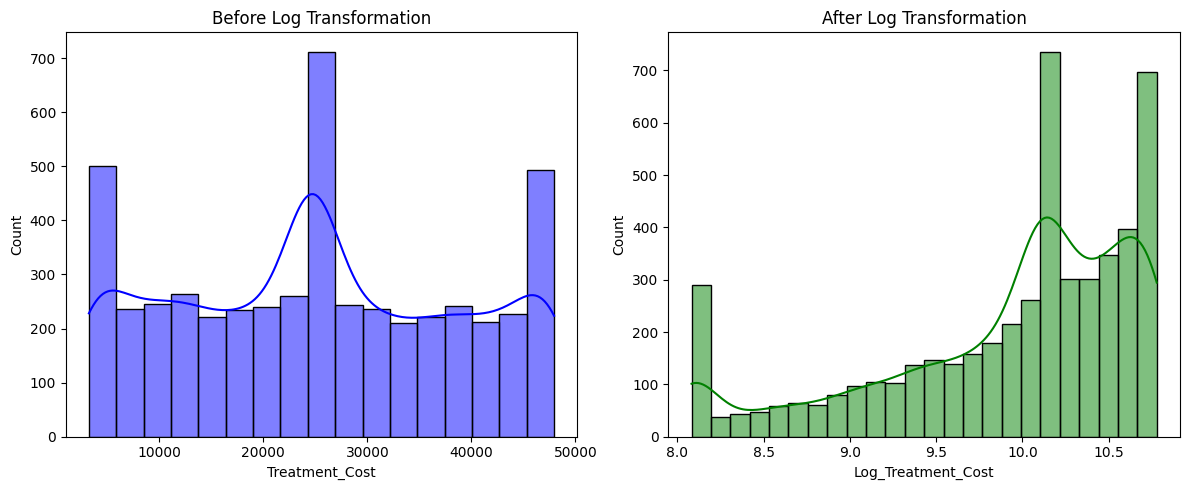

Skewness before: 0.06
Skewness after: -1.03


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Apply Log Transformation and create a new column
# We use log1p (log 1+x) to handle any zero values if present
df['Log_Treatment_Cost'] = np.log1p(df['Treatment_Cost'])

# 2. Compare Before vs After Distribution
plt.figure(figsize=(12, 5))

# Before Transformation
plt.subplot(1, 2, 1)
sns.histplot(df['Treatment_Cost'], kde=True, color='blue')
plt.title('Before Log Transformation')

# After Transformation
plt.subplot(1, 2, 2)
sns.histplot(df['Log_Treatment_Cost'], kde=True, color='green')
plt.title('After Log Transformation')

plt.tight_layout()
plt.show()

# 3. Check Skewness
print(f"Skewness before: {df['Treatment_Cost'].skew():.2f}")
print(f"Skewness after: {df['Log_Treatment_Cost'].skew():.2f}")

Q9. Time-Based Missing Handling

Scenario:
 Admission dates should follow a logical sequence.
Task:
Sort data by Admission_Date
Apply forward fill or backward fill where appropriate
Justify your choice

In [15]:
# 1. Convert Admission_Date to datetime format (Safety step)
df['Admission_Date'] = pd.to_datetime(df['Admission_Date'])

# 2. Sort the data by Admission_Date
df = df.sort_values(by='Admission_Date')

# 3. Apply Forward Fill (ffill)
# This fills the missing date with the date from the previous row
df['Admission_Date'] = df['Admission_Date'].ffill()

# 4. Verification
print("Missing values in Admission_Date:", df['Admission_Date'].isnull().sum())
print("\nFirst 5 rows after sorting and filling:")
print(df[['Patient_ID', 'Admission_Date']].head())

Missing values in Admission_Date: 0

First 5 rows after sorting and filling:
      Patient_ID Admission_Date
2932       19591     2023-01-01
4617       10896     2023-01-01
2642       19262     2023-01-01
4837       12843     2023-01-01
2702       17230     2023-01-01


/tmp/ipykernel_5503/2597343397.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Admission_Date'] = pd.to_datetime(df['Admission_Date'])
